# PF2315 Earbud CSV Analysis

This notebook analyzes CSV files produced by the PF2315 Python logger.

It focuses on:

- **IR PPG** channels: `ir1` to `ir4`
- **RED PPG** channels: `red1` to `red4`
- **G-sensor / accelerometer** channels: `accel_x_g`, `accel_y_g`, `accel_z_g`
- Basic stream quality checks, repeat-channel checks, motion artifact inspection, and frequency-domain views.

The PF2315 raw stream is expected to run at **75 Hz**. The notebook uses that as the nominal sampling rate, but also estimates the observed rate from timestamps when available.

In [ ]:
# ===== User settings =====
from pathlib import Path

# Put this notebook in the same folder as your CSV, or change this path.
CSV_PATH = Path("pf2315_readings.csv")

# Nominal PF2315 raw-data sampling rate.
FS = 30.0

# Optional analysis window in seconds. Set END_S = None to analyze to the end.
START_S = 0
END_S = None

# Rolling baseline window for normalized PPG AC signal.
# Longer windows remove slow drift while preserving pulse-wave variation.
BASELINE_WINDOW_SECONDS = 2.0

# Heart-rate-like band for exploratory spectral analysis, in Hz.
# 0.7-3.0 Hz corresponds approximately to 42-180 bpm.
PPG_BAND_HZ = (0.7, 3.0)

## 1. Imports and helper functions

In [ ]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import signal
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    signal = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

IR_COLS = ["ir1", "ir2", "ir3", "ir4"]
IR_REPEAT_COLS = ["ir1_repeat", "ir2_repeat", "ir3_repeat", "ir4_repeat"]
RED_COLS = ["red1", "red2", "red3", "red4"]
ACCEL_G_COLS = ["accel_x_g", "accel_y_g", "accel_z_g"]
ACCEL_RAW_COLS = ["accel_x_raw", "accel_y_raw", "accel_z_raw"]

EXPECTED_COLS = [
    "host_time_iso", "host_time_unix_ns", "sample_index", "record_type",
    *IR_COLS, *IR_REPEAT_COLS, *RED_COLS,
    *ACCEL_RAW_COLS, *ACCEL_G_COLS,
    "reserved", "heart_rate", "debug",
]


def require_columns(df, columns, label="required"):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing {label} columns: {missing}")


def coerce_numeric(df, columns):
    for c in columns:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def make_time_axis(df, fs=75.0):
    """Add elapsed-time columns using timestamps when available, otherwise sample_index/fs."""
    out = df.copy()

    if "host_time_iso" in out.columns:
        out["host_time"] = pd.to_datetime(out["host_time_iso"], errors="coerce", utc=True)
    else:
        out["host_time"] = pd.NaT

    if out["host_time"].notna().sum() >= 2:
        t0 = out["host_time"].dropna().iloc[0]
        out["elapsed_s_host"] = (out["host_time"] - t0).dt.total_seconds()
    else:
        out["elapsed_s_host"] = np.nan

    if "sample_index" in out.columns and out["sample_index"].notna().sum() > 0:
        idx0 = out["sample_index"].dropna().iloc[0]
        out["elapsed_s_sample"] = (out["sample_index"] - idx0) / fs
    else:
        out["elapsed_s_sample"] = np.arange(len(out)) / fs

    # Prefer host time if it is monotonic enough; otherwise use nominal sample clock.
    host_ok = (
        out["elapsed_s_host"].notna().sum() >= 2
        and out["elapsed_s_host"].dropna().is_monotonic_increasing
        and out["elapsed_s_host"].max() > 0
    )
    out["elapsed_s"] = out["elapsed_s_host"] if host_ok else out["elapsed_s_sample"]

    return out


def estimate_sampling_rate(df):
    """Estimate sampling rate from host timestamps if present."""
    if "elapsed_s_host" not in df.columns:
        return np.nan
    t = df["elapsed_s_host"].dropna().to_numpy()
    if len(t) < 3:
        return np.nan
    diffs = np.diff(t)
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if len(diffs) == 0:
        return np.nan
    return 1.0 / np.median(diffs)


def rolling_median_baseline(x, fs=75.0, seconds=2.0):
    """Rolling median baseline. Window is forced to an odd integer."""
    window = max(3, int(round(seconds * fs)))
    if window % 2 == 0:
        window += 1
    return pd.Series(x).rolling(window=window, center=True, min_periods=max(3, window // 4)).median().to_numpy()


def normalized_ac_percent(x, fs=75.0, seconds=2.0):
    """Return 100 * (x - rolling_baseline) / baseline."""
    x = np.asarray(x, dtype=float)
    base = rolling_median_baseline(x, fs=fs, seconds=seconds)
    y = 100.dpass(x, fs=75.0, low=0.7, high=3.0, order=3):
    """Bandpass filter if SciPy is available; otherwise return demeaned data."""
    x = np.asarray(x, dtype=float)
    x = pd.Series(x).interpolate(limit_direction="both").to_numpy()

    if not SCIPY_AVAILABLE:
        return x - np.nanmedian(x)

    nyq = fs / 2.0
    low = max(low, 0.001)
    high = min(high, nyq * 0.95)
    if not (0 < low < high < nyq):
        return x - np.nanmedian(x)

    sos = signal.butter(order, [low / nyq, high / nyq], btype="bandpass", output="sos")
    padlen = min(len(x) - 1, 3 * (2 * len(sos) + 1))
    if len(x) <= 10 or padlen <= 0:
        return x - np.nanmedian(x)
    return signal.sosfiltfilt(sos, x, padlen=padlen)


def welch_psd(x, fs=75.0):
    """Welch PSD if SciPy is available; simple FFT periodogram otherwise."""
    x = np.asarray(x, dtype=float)
    x = pd.Series(x).interpolate(limit_direction="both").to_numpy()
    x = x - np.nanmean(x)

    if len(x) < 8:
        return np.array([]), np.array([])

    if SCIPY_AVAILABLE:
        nperseg = min(len(x), int(fs * 8))
        if nperseg < 8:
            nperseg = min(len(x), 8)
        f, pxx = signal.welch(x, fs=fs, nperseg=nperseg)
        return f, pxx

    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    power = np.abs(np.fft.rfft(x)) ** 2 / len(x)
    return freqs, power


def dominant_frequency_bpm(x, fs=75.0, band=(0.7, 3.0)):
    """Estimate dominant frequency inside a PPG band. Exploratory only, not clinical."""
    f, pxx = welch_psd(x, fs=fs)
    if len(f) == 0:
        return np.nan, np.nan
    mask = (f >= band[0]) & (f <= band[1])
    if not np.any(mask):
        return np.nan, np.nan
    fb = f[mask]
    pb = pxx[mask]
    if len(pb) == 0 or np.all(~np.isfinite(pb)):
        return np.nan, np.nan
    f_peak = fb[np.nanargmax(pb)]
    return f_peak, f_peak * 60.0


def plot_lines(df, columns, title, ylabel, xcol="elapsed_s", max_points=None):
    """Plot selected columns against elapsed seconds."""
    plot_df = df
    if max_points is not None and len(df) > max_points:
        step = int(math.ceil(len(df) / max_points))
        plot_df = df.iloc[::step]

    fig, ax = plt.subplots(figsize=(14, 5))
    for c in columns:
        if c in plot_df.columns:
            ax.plot(plot_df[xcol], plot_df[c], label=c, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()


def segment_df(df, start_s=0.0, end_s=None):
    mask = df["elapsed_s"] >= float(start_s)
    if end_s is not None:
        mask &= df["elapsed_s"] <= float(end_s)
    return df.loc[mask].copy()

## 2. Load the CSV

Place the notebook in the same folder as `pf2315_readings.csv`, or edit `CSV_PATH` in the first cell.

In [42]:
if not CSV_PATH.exists():
    nearby = sorted(Path.cwd().glob("*.csv"))
    print(f"Current working directory: {Path.cwd()}")
    print("CSV_PATH does not exist:", CSV_PATH)
    print("Nearby CSV files:")
    for p in nearby[:20]:
        print(" -", p)
    raise FileNotFoundError(f"Could not find {CSV_PATH}. Update CSV_PATH and rerun this cell.")

raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw):,} rows and {len(raw.columns):,} columns from {CSV_PATH}")
print("Columns:")
print(list(raw.columns))

raw.head()

Loaded 2,435 rows and 25 columns from pf2315_readings.csv
Columns:
['host_time_iso', 'host_time_unix_ns', 'sample_index', 'record_type', 'ir1', 'ir2', 'ir3', 'ir4', 'ir1_repeat', 'ir2_repeat', 'ir3_repeat', 'ir4_repeat', 'red1', 'red2', 'red3', 'red4', 'accel_x_raw', 'accel_y_raw', 'accel_z_raw', 'accel_x_g', 'accel_y_g', 'accel_z_g', 'reserved', 'heart_rate', 'debug']


,host_time_iso,host_time_unix_ns,sample_index,record_type,ir1,ir2,ir3,ir4,ir1_repeat,ir2_repeat,ir3_repeat,ir4_repeat,red1,red2,red3,red4,accel_x_raw,accel_y_raw,accel_z_raw,accel_x_g,accel_y_g,accel_z_g,reserved,heart_rate,debug
0,2026-05-22T02:37:45.500+00:00,1779417465501939000,1,R,7482,7763,8994,10194,7482,7763,8994,10194,19095,23410,18433,22074,-126,-219,-15,-0.494118,-0.858824,-0.058824,1,255,e00
1,2026-05-22T02:37:45.502+00:00,1779417465502210000,2,R,7485,7765,8991,10194,7485,7765,8991,10194,19095,23405,18432,22079,-128,-220,-16,-0.501961,-0.862745,-0.062745,1,255,f00
2,2026-05-22T02:37:45.502+00:00,1779417465502346000,3,R,7487,7765,8992,10196,7487,7765,8992,10196,19098,23403,18431,22079,-127,-221,-16,-0.498039,-0.866667,-0.062745,1,255,000
3,2026-05-22T02:37:45.502+00:00,1779417465502410000,4,R,7486,7766,8991,10195,7486,7766,8991,10195,19097,23400,18429,22078,-125,-222,-17,-0.490196,-0.870588,-0.066667,1,255,100
4,2026-05-22T02:37:45.502+00:00,1779417465502452000,5,R,7485,7761,8989,10194,7485,7761,8989,10194,19093,23401,18426,22081,-126,-223,-16,-0.494118,-0.874510,-0.062745,1,255,200


## 3. Validate and prepare the data

This cell checks that the important columns exist, converts numeric fields, creates elapsed-time axes, and creates derived mean PPG and motion signals.

In [43]:
require_columns(raw, IR_COLS, "IR")
require_columns(raw, RED_COLS, "RED")
require_columns(raw, ACCEL_G_COLS, "accelerometer g")

numeric_cols = [
    "host_time_unix_ns", "sample_index",
    *IR_COLS, *IR_REPEAT_COLS, *RED_COLS,
    *ACCEL_RAW_COLS, *ACCEL_G_COLS,
    "reserved", "heart_rate",
]

df = raw.copy()
df = coerce_numeric(df, numeric_cols)
df = make_time_axis(df, fs=FS)

# Derived PPG means.
df["ir_mean"] = df[IR_COLS].mean(axis=1)
df["red_mean"] = df[RED_COLS].mean(axis=1)

# Derived normalized AC PPG estimates.
df["ir_ac_pct"] = normalized_ac_percent(df["ir_mean"], fs=FS, seconds=BASELINE_WINDOW_SECONDS)
df["red_ac_pct"] = normalized_ac_percent(df["red_mean"], fs=FS, seconds=BASELINE_WINDOW_SECONDS)

# Derived accelerometer motion signals.
df["accel_mag_g"] = np.sqrt(
    df["accel_x_g"] ** 2 + df["accel_y_g"] ** 2 + df["accel_z_g"] ** 2
)
df["accel_dynamic_g"] = df["accel_mag_g"] - rolling_median_baseline(
    df["accel_mag_g"], fs=FS, seconds=BASELINE_WINDOW_SECONDS
)

analysis = segment_df(df, START_S, END_S)

observed_fs = estimate_sampling_rate(df)
print(f"Rows loaded: {len(df):,}")
print(f"Rows in selected analysis window: {len(analysis):,}")
print(f"Nominal FS: {FS:.3f} Hz")
if np.isfinite(observed_fs):
    print(f"Observed median host-timestamp FS: {observed_fs:.3f} Hz")
else:
    print("Observed FS could not be estimated from host timestamps.")

print(f"Elapsed duration from selected axis: {analysis['elapsed_s'].max() - analysis['elapsed_s'].min():.2f} s")
analysis.head()

Rows loaded: 2,435
Rows in selected analysis window: 2,435
Nominal FS: 30.000 Hz
Observed median host-timestamp FS: 6.711 Hz
Elapsed duration from selected axis: 76.65 s


,host_time_iso,host_time_unix_ns,sample_index,record_type,ir1,ir2,ir3,ir4,ir1_repeat,ir2_repeat,ir3_repeat,ir4_repeat,red1,red2,red3,red4,accel_x_raw,accel_y_raw,accel_z_raw,accel_x_g,accel_y_g,accel_z_g,reserved,heart_rate,debug,host_time,elapsed_s_host,elapsed_s_sample,elapsed_s,ir_mean,red_mean,ir_ac_pct,red_ac_pct,accel_mag_g,accel_dynamic_g
0,2026-05-22T02:37:45.500+00:00,1779417465501939000,1,R,7482,7763,8994,10194,7482,7763,8994,10194,19095,23410,18433,22074,-126,-219,-15,-0.494118,-0.858824,-0.058824,1,255,e00,2026-05-22 02:37:45.500000+00:00,0.000,0.000000,0.000,8608.25,20753.00,-0.104442,-0.036126,0.992568,-0.009060
1,2026-05-22T02:37:45.502+00:00,1779417465502210000,2,R,7485,7765,8991,10194,7485,7765,8991,10194,19095,23405,18432,22079,-128,-220,-16,-0.501961,-0.862745,-0.062745,1,255,f00,2026-05-22 02:37:45.502000+00:00,0.002,0.033333,0.002,8608.75,20752.75,-0.113129,-0.043951,1.000115,-0.001471
2,2026-05-22T02:37:45.502+00:00,1779417465502346000,3,R,7487,7765,8992,10196,7487,7765,8992,10196,19098,23403,18431,22079,-127,-221,-16,-0.498039,-0.866667,-0.062745,1,255,000,2026-05-22 02:37:45.502000+00:00,0.002,0.066667,0.002,8610.00,20752.75,-0.113112,-0.050570,1.001545,-0.000084
3,2026-05-22T02:37:45.502+00:00,1779417465502410000,4,R,7486,7766,8991,10195,7486,7766,8991,10195,19097,23400,18429,22078,-125,-222,-17,-0.490196,-0.870588,-0.066667,1,255,100,2026-05-22 02:37:45.502000+00:00,0.002,0.100000,0.002,8609.50,20751.00,-0.127603,-0.060202,1.001329,-0.000411
4,2026-05-22T02:37:45.502+00:00,1779417465502452000,5,R,7485,7761,8989,10194,7485,7761,8989,10194,19093,23401,18426,22081,-126,-223,-16,-0.494118,-0.874510,-0.062745,1,255,200,2026-05-22 02:37:45.502000+00:00,0.002,0.133333,0.002,8607.25,20750.25,-0.162389,-0.065017,1.006408,0.004557


## 4. Stream quality checks

This section checks sample-index gaps, timestamp gaps, missing values, and whether the repeated IR columns match the original IR columns.

In [44]:
quality_rows = []

for c in IR_COLS + RED_COLS + ACCEL_G_COLS + ["heart_rate"]:
    if c in df.columns:
        quality_rows.append({
            "column": c,
            "missing": int(df[c].isna().sum()),
            "min": df[c].min(),
            "max": df[c].max(),
            "mean": df[c].mean(),
            "std": df[c].std(),
            "unique_values": int(df[c].nunique(dropna=True)),
        })

quality = pd.DataFrame(quality_rows)
display(quality)

if "sample_index" in df.columns and df["sample_index"].notna().sum() > 1:
    idx_diff = df["sample_index"].diff()
    print("Sample-index diff summary:")
    display(idx_diff.describe())
    gaps = df.loc[idx_diff > 1, ["sample_index", "elapsed_s"]].copy()
    print(f"Detected sample-index gaps > 1: {len(gaps):,}")
    display(gaps.head(20))

if "elapsed_s_host" in df.columns and df["elapsed_s_host"].notna().sum() > 1:
    dt_host = df["elapsed_s_host"].diff()
    print("Host timestamp delta summary, seconds:")
    display(dt_host.describe())
    large_gaps = df.loc[dt_host > (3.0 / FS), ["sample_index", "elapsed_s_host"]].copy()
    print(f"Host timestamp gaps > 3 nominal samples: {len(large_gaps):,}")
    display(large_gaps.head(20))

if all(c in df.columns for c in IR_REPEAT_COLS):
    repeat_check = pd.DataFrame({
        f"{a}_minus_{b}": df[a] - df[b]
        for a, b in zip(IR_COLS, IR_REPEAT_COLS)
    })
    print("IR repeat-column difference summary. Ideally these are all zero or very close to zero.")
    display(repeat_check.describe())

,column,missing,min,max,mean,std,unique_values
0,ir1,0,7482.000000,7851.000000,7668.664887,73.294334,286
1,ir2,0,7754.000000,7984.000000,7891.042300,53.792301,225
2,ir3,0,8989.000000,9278.000000,9161.520739,63.879971,271
3,ir4,0,10193.000000,10495.000000,10381.611499,67.425672,288
4,red1,0,19066.000000,19470.000000,19162.426694,39.527352,193
5,red2,0,23078.000000,23552.000000,23379.361807,62.223080,317
6,red3,0,18304.000000,18500.000000,18396.135934,29.301566,167
7,red4,0,22058.000000,22320.000000,22125.794661,37.894847,203
8,accel_x_g,0,-0.580392,-0.090196,-0.408621,0.116275,93
9,accel_y_g,0,-1.035294,-0.760784,-0.895369,0.045894,57


Sample-index diff summary:


count    2434.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: sample_index, dtype: float64

Detected sample-index gaps > 1: 0


,sample_index,elapsed_s


...

count    2434.000000
mean        0.031492
std         0.071129
min         0.000000
25%         0.000000
50%         0.000000
75%         0.001000
max         0.599000
Name: elapsed_s_host, dtype: float64

Host timestamp gaps > 3 nominal samples: 439


,sample_index,elapsed_s_host
6,7,0.150
11,12,0.300
16,17,0.449
22,23,0.599
27,28,0.749
32,33,0.899
38,39,1.051
43,44,1.200
48,49,1.351
53,54,1.499


IR repeat-column difference summary. Ideally these are all zero or very close to zero.


,ir1_minus_ir1_repeat,ir2_minus_ir2_repeat,ir3_minus_ir3_repeat,ir4_minus_ir4_repeat
count,2435.0,2435.0,2435.0,2435.0
mean,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0


## 5. Raw IR and RED PPG channels

The PF2315 has four IR photodiode readings and four RED photodiode readings per sample. Start with raw traces to check drift, clipping, noise, and channel consistency.

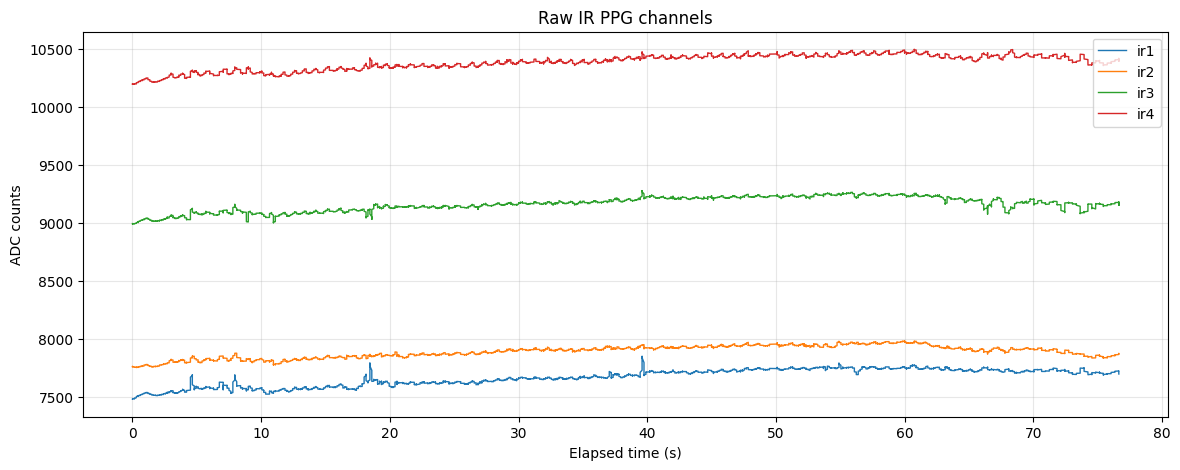

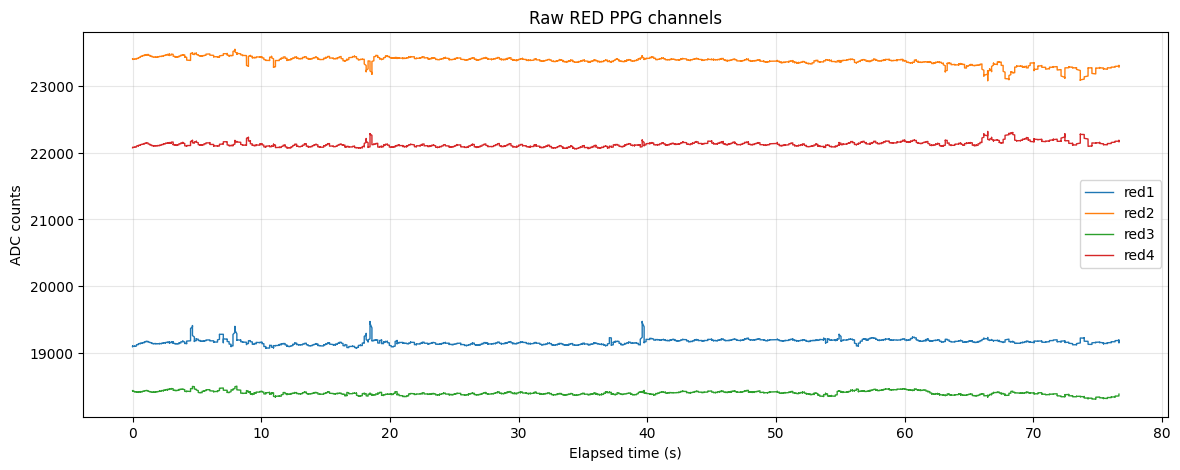

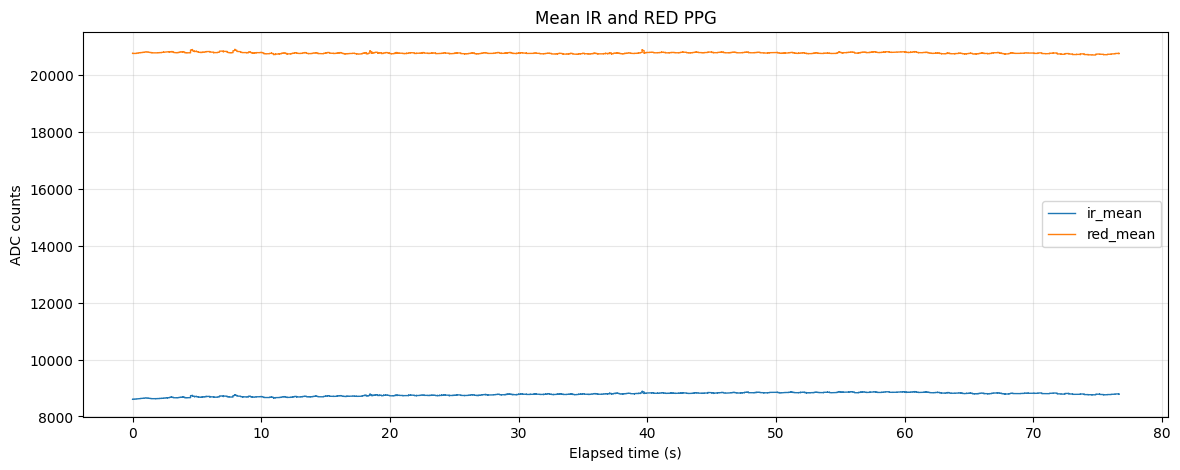

In [45]:
plot_lines(analysis, IR_COLS, "Raw IR PPG channels", "ADC counts", max_points=15000)
plot_lines(analysis, RED_COLS, "Raw RED PPG channels", "ADC counts", max_points=15000)
plot_lines(analysis, ["ir_mean", "red_mean"], "Mean IR and RED PPG", "ADC counts", max_points=15000)

## 6. Normalized PPG AC components

The raw PPG contains a large DC baseline. This section subtracts a rolling median baseline and expresses the remaining signal as a percentage of the baseline.

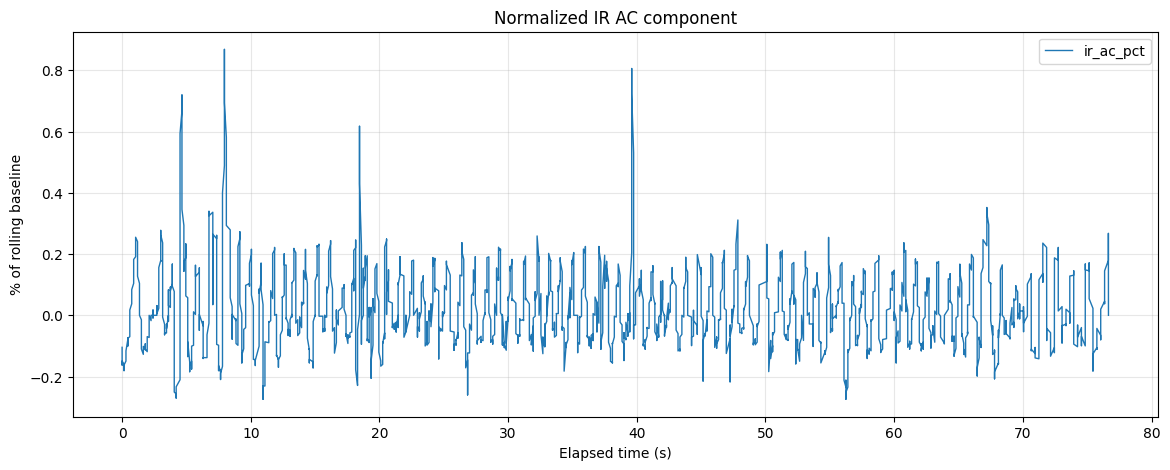

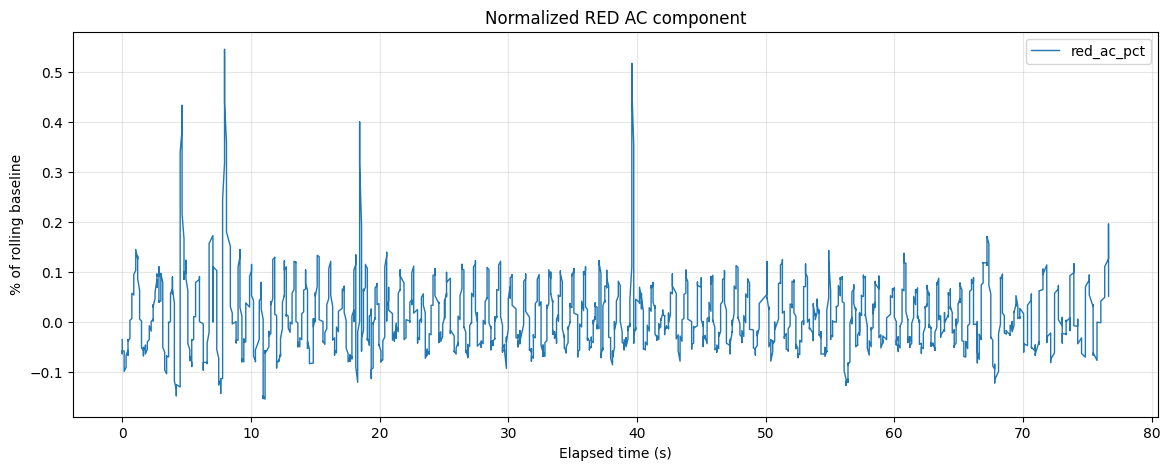

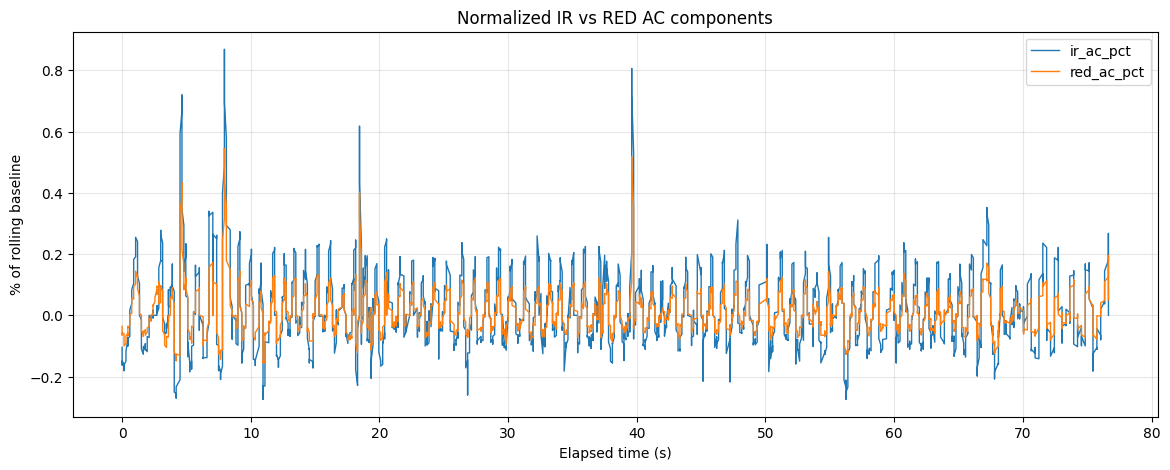

In [46]:
plot_lines(analysis, ["ir_ac_pct"], "Normalized IR AC component", "% of rolling baseline", max_points=15000)
plot_lines(analysis, ["red_ac_pct"], "Normalized RED AC component", "% of rolling baseline", max_points=15000)
plot_lines(analysis, ["ir_ac_pct", "red_ac_pct"], "Normalized IR vs RED AC components", "% of rolling baseline", max_points=15000)

## 7. G-sensor / accelerometer analysis

The logger already converts raw accelerometer values using the manual scale of `255 = 1G`. This section plots x/y/z acceleration, magnitude, and dynamic movement.

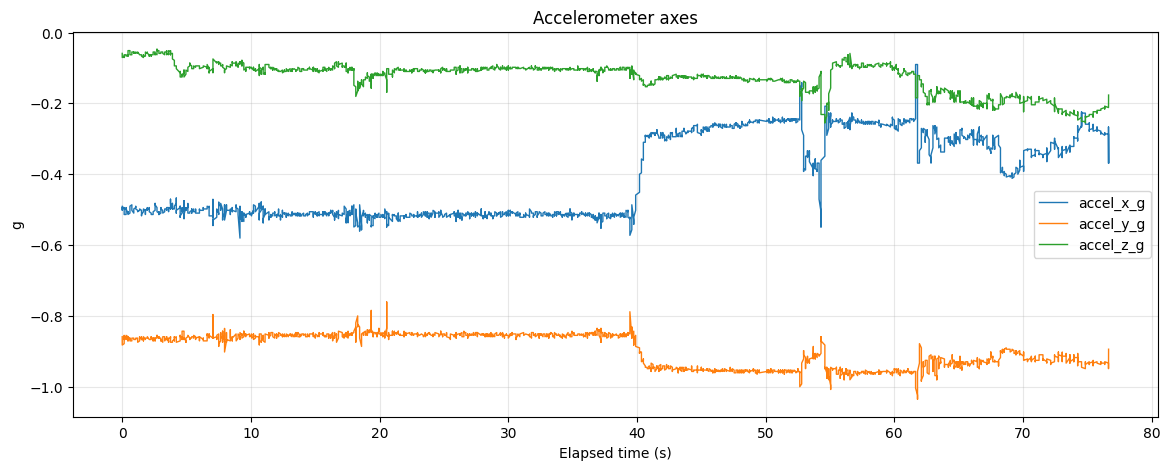

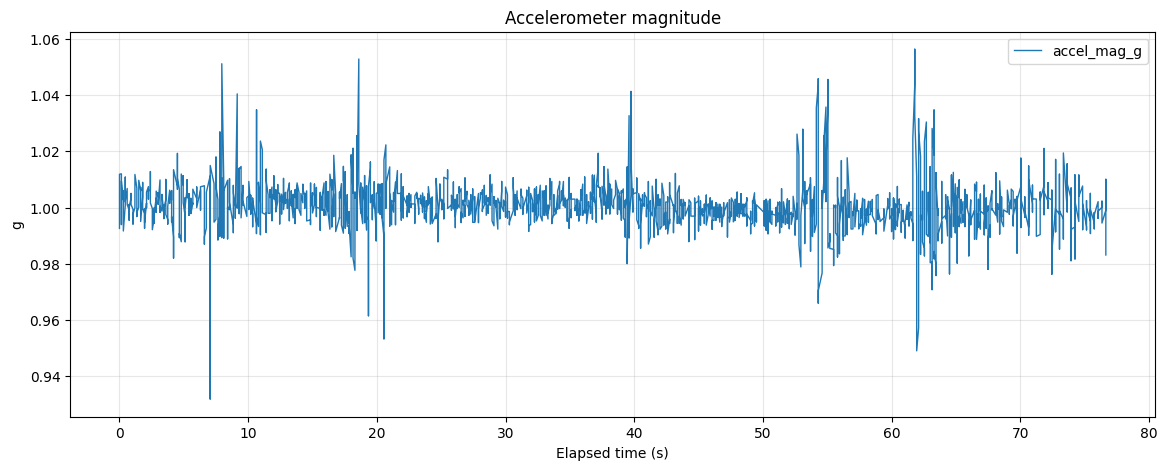

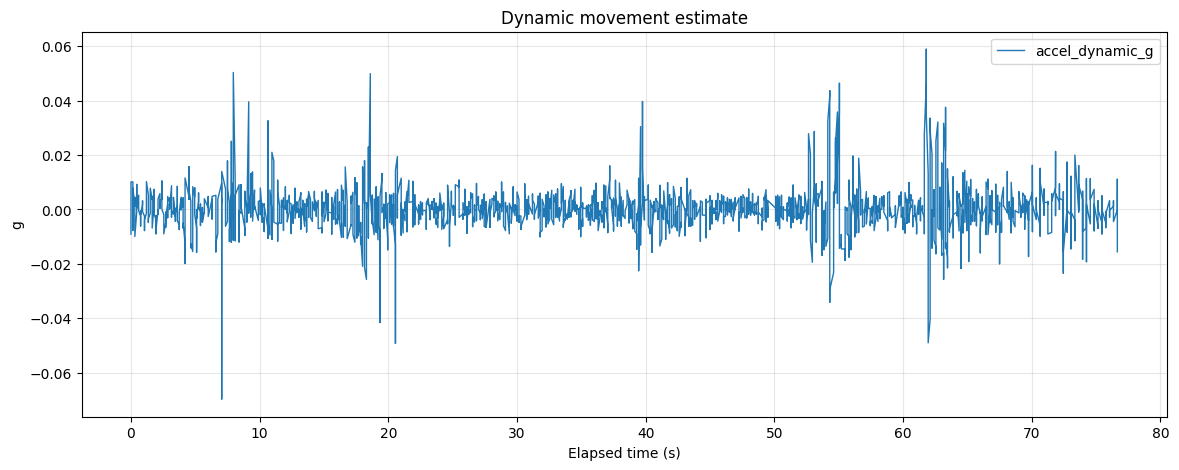

In [47]:
plot_lines(analysis, ACCEL_G_COLS, "Accelerometer axes", "g", max_points=15000)
plot_lines(analysis, ["accel_mag_g"], "Accelerometer magnitude", "g", max_points=15000)
plot_lines(analysis, ["accel_dynamic_g"], "Dynamic movement estimate", "g", max_points=15000)

## 8. PPG plus motion overlay

Motion is one of the most important confounders for earbud PPG. This plot overlays normalized PPG with accelerometer dynamic magnitude.

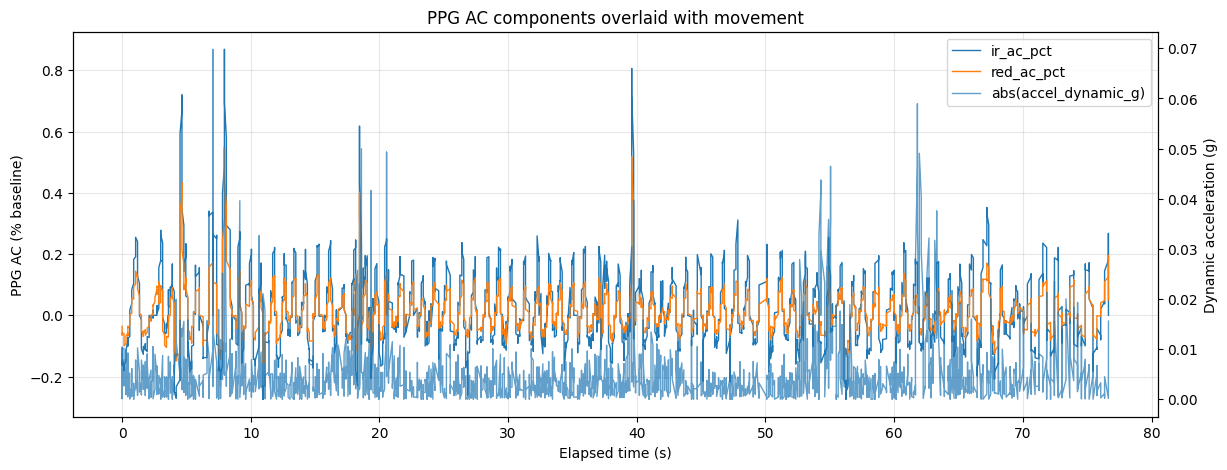

In [48]:
plot_df = analysis.copy()
if len(plot_df) > 15000:
    step = int(math.ceil(len(plot_df) / 15000))
    plot_df = plot_df.iloc[::step]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(plot_df["elapsed_s"], plot_df["ir_ac_pct"], label="ir_ac_pct", linewidth=1)
ax1.plot(plot_df["elapsed_s"], plot_df["red_ac_pct"], label="red_ac_pct", linewidth=1)
ax1.set_xlabel("Elapsed time (s)")
ax1.set_ylabel("PPG AC (% baseline)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(plot_df["elapsed_s"], plot_df["accel_dynamic_g"].abs(), label="abs(accel_dynamic_g)", linewidth=1, alpha=0.7)
ax2.set_ylabel("Dynamic acceleration (g)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.set_title("PPG AC components overlaid with movement")
plt.show()

## 9. Frequency-domain view and exploratory pulse estimate

This section estimates the dominant spectral peak in a configurable band. Treat this as a signal-quality diagnostic, not as a medical heart-rate estimate.

IR dominant peak:  0.998 Hz = 59.9 bpm
RED dominant peak: 0.998 Hz = 59.9 bpm


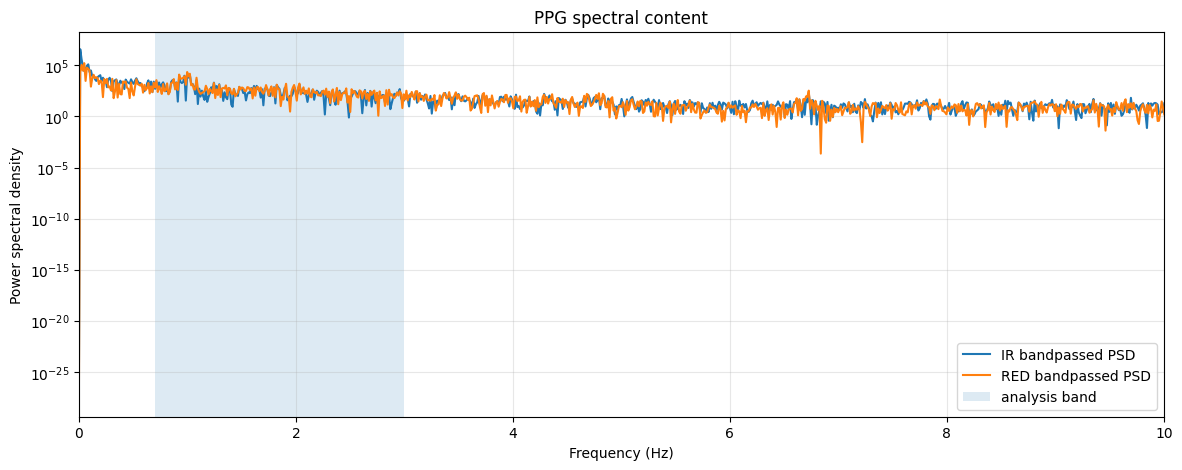

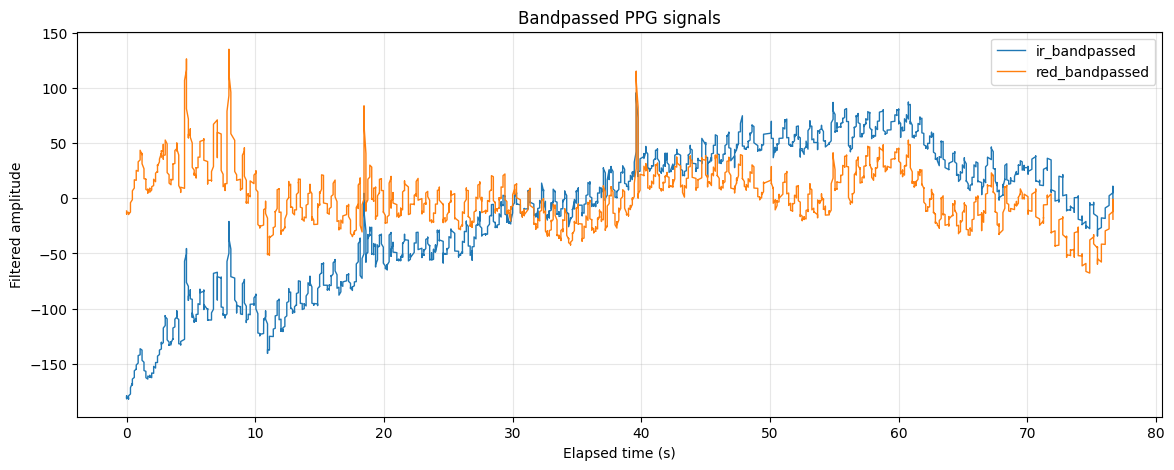

In [49]:
low_hz, high_hz = PPG_BAND_HZ

ir_band = safe_bandpass(analysis["ir_mean"], fs=FS, low=low_hz, high=high_hz)
red_band = safe_bandpass(analysis["red_mean"], fs=FS, low=low_hz, high=high_hz)

ir_f_peak, ir_bpm_peak = dominant_frequency_bpm(ir_band, fs=FS, band=PPG_BAND_HZ)
red_f_peak, red_bpm_peak = dominant_frequency_bpm(red_band, fs=FS, band=PPG_BAND_HZ)

print(f"IR dominant peak:  {ir_f_peak:.3f} Hz = {ir_bpm_peak:.1f} bpm")
print(f"RED dominant peak: {red_f_peak:.3f} Hz = {red_bpm_peak:.1f} bpm")

f_ir, p_ir = welch_psd(ir_band, fs=FS)
f_red, p_red = welch_psd(red_band, fs=FS)

fig, ax = plt.subplots(figsize=(14, 5))
if len(f_ir):
    ax.semilogy(f_ir, p_ir, label="IR bandpassed PSD")
if len(f_red):
    ax.semilogy(f_red, p_red, label="RED bandpassed PSD")
ax.axvspan(low_hz, high_hz, alpha=0.15, label="analysis band")
ax.set_xlim(0, min(10, FS / 2))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power spectral density")
ax.set_title("PPG spectral content")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

plot_tmp = pd.DataFrame({
    "elapsed_s": analysis["elapsed_s"].to_numpy(),
    "ir_bandpassed": ir_band,
    "red_bandpassed": red_band,
})
plot_lines(plot_tmp, ["ir_bandpassed", "red_bandpassed"], "Bandpassed PPG signals", "Filtered amplitude", max_points=15000)

## 10. Channel agreement and correlations

This gives a quick view of how similar the four IR channels are, how similar the four RED channels are, and how PPG features correlate with movement.

,ir1,ir2,ir3,ir4,red1,red2,red3,red4,ir_mean,red_mean,ir_ac_pct,red_ac_pct,accel_mag_g,accel_dynamic_g
ir1,1.000000,0.909051,0.908144,0.965625,0.601020,-0.542690,-0.043371,0.441242,0.972478,0.055188,0.128357,0.138243,-0.138090,0.023611
ir2,0.909051,1.000000,0.963928,0.955716,0.447291,-0.283157,0.158737,0.235769,0.976924,0.138477,0.116551,0.108177,-0.133101,0.009447
ir3,0.908144,0.963928,1.000000,0.924922,0.450461,-0.214385,0.060938,0.142447,0.969873,0.118207,0.128713,0.122015,-0.145962,-0.009899
ir4,0.965625,0.955716,0.924922,1.000000,0.492784,-0.483972,0.010945,0.436037,0.985878,0.062998,0.136512,0.134133,-0.130809,0.019210
red1,0.601020,0.447291,0.450461,0.492784,1.000000,-0.102073,0.358850,0.564071,0.515799,0.660230,0.510230,0.552205,-0.024228,0.074146
red2,-0.542690,-0.283157,-0.214385,-0.483972,-0.102073,1.000000,0.516652,-0.513307,-0.401712,0.546676,0.250122,0.234320,0.057817,-0.043685
red3,-0.043371,0.158737,0.060938,0.010945,0.358850,0.516652,1.000000,0.225741,0.039605,0.854260,0.335951,0.337966,-0.029919,0.011779
red4,0.441242,0.235769,0.142447,0.436037,0.564071,-0.513307,0.225741,1.000000,0.331101,0.353787,0.318678,0.346416,-0.042537,0.061027
ir_mean,0.972478,0.976924,0.969873,0.985878,0.515799,-0.401712,0.039605,0.331101,1.000000,0.092337,0.131231,0.129986,-0.140432,0.011503
red_mean,0.055188,0.138477,0.118207,0.062998,0.660230,0.546676,0.854260,0.353787,0.092337,1.000000,0.584993,0.603116,0.001535,0.029125


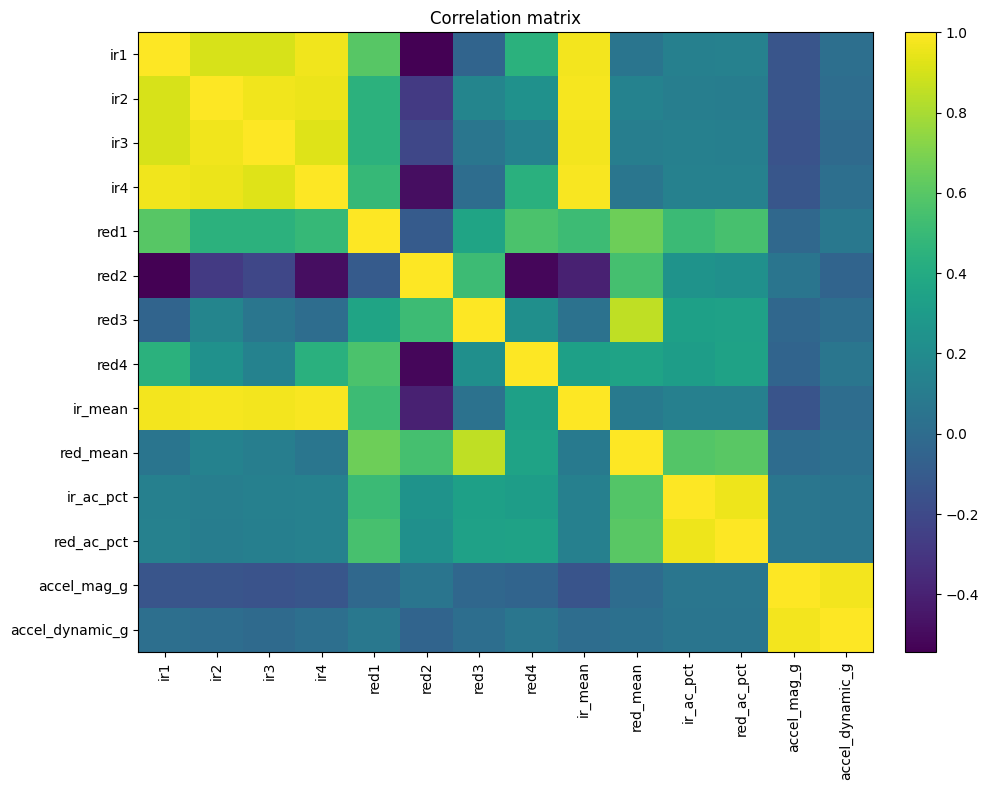

,metric,correlation
0,abs(IR AC) vs movement,0.104802
1,abs(RED AC) vs movement,0.096088
2,IR AC vs RED AC,0.962469


In [50]:
cor_cols = IR_COLS + RED_COLS + ["ir_mean", "red_mean", "ir_ac_pct", "red_ac_pct", "accel_mag_g", "accel_dynamic_g"]
cor_cols = [c for c in cor_cols if c in analysis.columns]

corr = analysis[cor_cols].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

movement_abs = analysis["accel_dynamic_g"].abs()
summary_corr = pd.DataFrame({
    "metric": ["abs(IR AC) vs movement", "abs(RED AC) vs movement", "IR AC vs RED AC"],
    "correlation": [
        analysis["ir_ac_pct"].abs().corr(movement_abs),
        analysis["red_ac_pct"].abs().corr(movement_abs),
        analysis["ir_ac_pct"].corr(analysis["red_ac_pct"]),
    ]
})
display(summary_corr)

## 11. Per-window summary table

This summarizes the recording in fixed windows. It is useful for finding stable and unstable sections.

,window_id,start_s,end_s,rows,ir_mean_mean,ir_ac_std_pct,red_mean_mean,red_ac_std_pct,accel_mag_mean_g,accel_dynamic_std_g,heart_rate_median,estimated_fs_from_rows
0,0,0.000,9.898,316,8671.854430,0.184285,20793.295095,0.107450,1.001876,0.008092,255.0,31.925642
1,1,10.050,19.950,337,8707.312315,0.121981,20757.062315,0.072560,1.002651,0.008098,72.0,34.040404
2,2,20.102,29.853,314,8750.931529,0.097578,20758.102707,0.053593,1.001792,0.005254,68.0,32.201825
3,3,30.002,39.902,338,8791.210799,0.123736,20751.227811,0.072870,1.002082,0.005466,66.0,34.141414
4,4,40.200,49.499,313,8828.209265,0.090237,20782.583866,0.045464,0.998845,0.004254,63.0,33.659533
5,5,50.098,59.851,323,8848.982972,0.104767,20776.690402,0.054902,0.999017,0.009385,63.0,33.118015
6,6,60.003,69.751,322,8824.687112,0.107014,20761.424689,0.053764,0.998768,0.011726,62.0,33.032417
7,7,70.048,76.652,172,8790.472384,0.103006,20734.127907,0.057918,0.999832,0.007690,63.0,26.044821


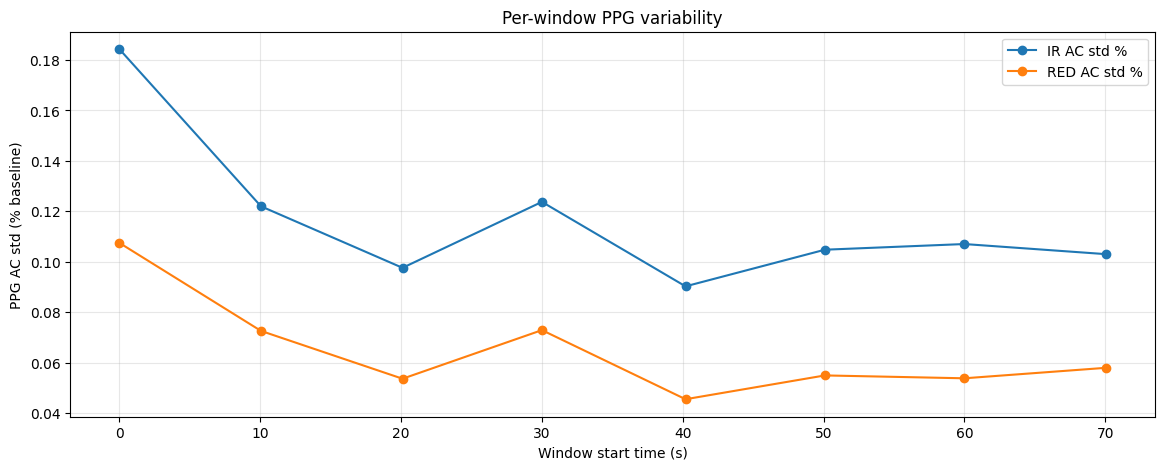

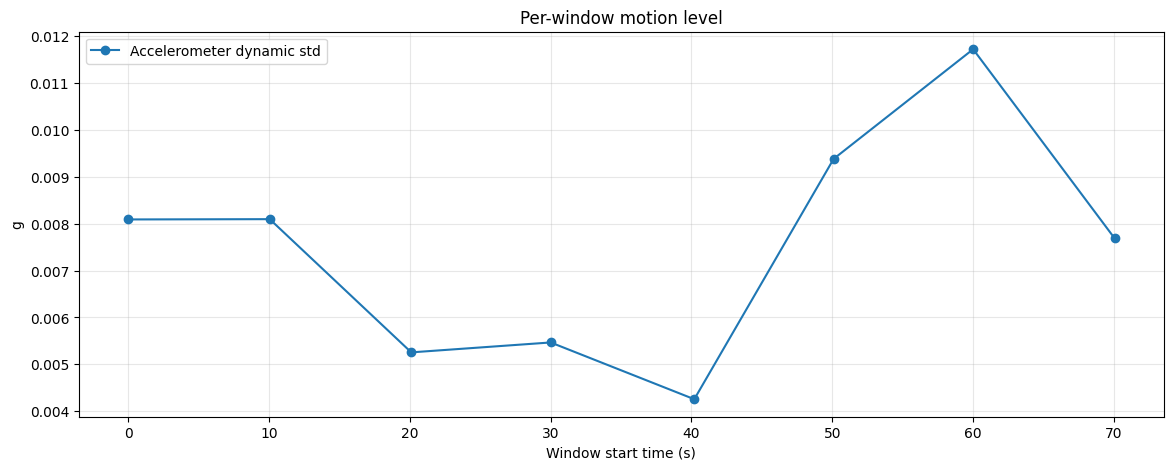

In [51]:
WINDOW_SECONDS = 10

work = analysis.copy()
work["window_id"] = np.floor((work["elapsed_s"] - work["elapsed_s"].min()) / WINDOW_SECONDS).astype(int)

window_summary = work.groupby("window_id").agg(
    start_s=("elapsed_s", "min"),
    end_s=("elapsed_s", "max"),
    rows=("elapsed_s", "size"),
    ir_mean_mean=("ir_mean", "mean"),
    ir_ac_std_pct=("ir_ac_pct", "std"),
    red_mean_mean=("red_mean", "mean"),
    red_ac_std_pct=("red_ac_pct", "std"),
    accel_mag_mean_g=("accel_mag_g", "mean"),
    accel_dynamic_std_g=("accel_dynamic_g", "std"),
    heart_rate_median=("heart_rate", "median"),
).reset_index()

window_summary["estimated_fs_from_rows"] = window_summary["rows"] / (window_summary["end_s"] - window_summary["start_s"]).replace(0, np.nan)

display(window_summary.head(30))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(window_summary["start_s"], window_summary["ir_ac_std_pct"], marker="o", label="IR AC std %")
ax.plot(window_summary["start_s"], window_summary["red_ac_std_pct"], marker="o", label="RED AC std %")
ax.set_xlabel("Window start time (s)")
ax.set_ylabel("PPG AC std (% baseline)")
ax.set_title("Per-window PPG variability")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(window_summary["start_s"], window_summary["accel_dynamic_std_g"], marker="o", label="Accelerometer dynamic std")
ax.set_xlabel("Window start time (s)")
ax.set_ylabel("g")
ax.set_title("Per-window motion level")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

## 12. Export cleaned/derived data

This writes a second CSV with the original fields plus derived columns such as `ir_mean`, `red_mean`, `ir_ac_pct`, `red_ac_pct`, and `accel_mag_g`.

In [52]:
EXPORT_CLEANED = True

if EXPORT_CLEANED:
    out_path = CSV_PATH.with_name(CSV_PATH.stem + "_derived.csv")
    df.to_csv(out_path, index=False)
    print(f"Wrote derived CSV to: {out_path.resolve()}")
else:
    print("EXPORT_CLEANED is False, so nothing was written.")

Wrote derived CSV to: /Users/brendanng/Documents/Synapxe/ppg_research_project/ppg_earbud/pf2315_readings_derived.csv


## 13. Notes for interpreting the plots

- IR and RED raw values should be continuous. Sudden flat-lining, huge jumps, or many missing values usually indicate poor contact, disconnection, or parsing problems.
- The repeated IR columns should match the first four IR columns. Large repeat differences suggest row parsing is still wrong.
- The accelerometer magnitude should often be near 1 g when the earbud is relatively still, because it includes gravity.
- Large `accel_dynamic_g` periods are likely motion-artifact periods for PPG.
- The spectral peak is only a diagnostic. For robust pulse estimation, use windowed quality screening, motion rejection, and peak tracking rather than a single global PSD peak.